# Smart Library Management — Data Mining Project

**Techniques:** Apriori, K-Means, Recommendation System  
**Dataset:** Library_Management_Dataset.xlsx

This notebook is intentionally kept concise for the project presentation and viva.

In [1]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
# 2. Load Dataset
df = pd.read_excel("Library_Management_Dataset.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (500, 9)


,Registration_No,Student_Name,Visit_Frequency_Per_Month,Books_Borrowed,Digital_Resources_Accessed,Reading_Duration_Hours,Preferred_Genre,Peak_Library_Hour,Reason_For_Visit
0,2022BCSE07AED001,PALLAMALA MUNI SIVA TEJA,24,12,8,1,Technology,1 PM,Borrow Books
1,2022BCSE07AED002,N NITHIN RAJ,11,14,14,34,Technology,10 AM,Exam Preparation
2,2022BCSE07AED004,MACHIREDDY KAMAL KUMAR,2,10,25,55,Business,10 AM,Reading
3,2022BCSE07AED005,PRINCE KUMAR,15,4,7,56,History,10 AM,Study
4,2022BCSE07AED006,AFRAH FATHIMA M K,9,5,49,42,Technology,9 AM,Exam Preparation



Missing Values:
Registration_No               0
Student_Name                  0
Visit_Frequency_Per_Month     0
Books_Borrowed                0
Digital_Resources_Accessed    0
Reading_Duration_Hours        0
Preferred_Genre               0
Peak_Library_Hour             0
Reason_For_Visit              0
dtype: int64


In [3]:
# 3. Basic Data Analysis
print("Total Students:", len(df))
print("Total Books Borrowed:", df["Books_Borrowed"].sum())
print("Total Digital Resources:", df["Digital_Resources_Accessed"].sum())
print("Average Reading Hours:", round(df["Reading_Duration_Hours"].mean(), 2))

print("\nPopular Genres:")
display(df["Preferred_Genre"].value_counts().head())

print("\nPeak Library Hours:")
display(df["Peak_Library_Hour"].value_counts().head())

Total Students: 500
Total Books Borrowed: 3811
Total Digital Resources: 12518
Average Reading Hours: 30.77

Popular Genres:


Preferred_Genre
Science        82
Technology     80
History        75
Non-Fiction    75
Business       65
Name: count, dtype: int64


Peak Library Hours:


Peak_Library_Hour
10 AM    68
9 AM     66
4 PM     65
12 PM    63
3 PM     63
Name: count, dtype: int64

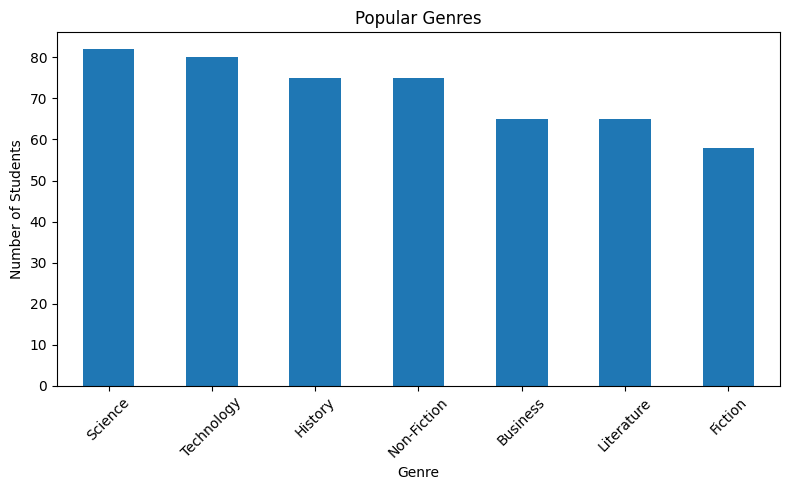

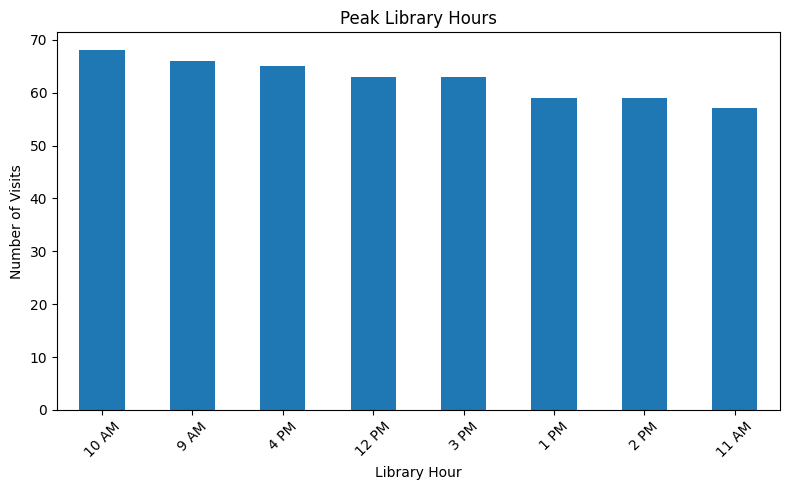

In [4]:
# 4. Basic Visualizations
plt.figure(figsize=(8, 5))
df["Preferred_Genre"].value_counts().plot(kind="bar")
plt.title("Popular Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
df["Peak_Library_Hour"].value_counts().plot(kind="bar")
plt.title("Peak Library Hours")
plt.xlabel("Library Hour")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Apriori Algorithm
Find relationships between preferred genre, reason for visit and peak library hour.

In [5]:
# Create transactions
transactions = df[
    ["Preferred_Genre", "Reason_For_Visit", "Peak_Library_Hour"]
].astype(str)

transactions = transactions.apply(lambda x: x.str.strip())

# Convert categories into 0/1 format
basket = pd.get_dummies(transactions)

# Find frequent itemsets
frequent_items = apriori(
    basket,
    min_support=0.05,
    use_colnames=True
)

# Generate association rules
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.30
)

rules = rules.sort_values("lift", ascending=False)

print("Top Apriori Rules:")
display(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

Top Apriori Rules:


,antecedents,consequents,support,confidence,lift


## 6. K-Means Clustering
Group students according to their library usage behaviour.

In [6]:
features = [
    "Visit_Frequency_Per_Month",
    "Books_Borrowed",
    "Digital_Resources_Accessed",
    "Reading_Duration_Hours"
]

X = df[features].copy()

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create 3 user groups
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Cluster profile
profile = df.groupby("Cluster")[features].mean().round(2)

print("Cluster Profile:")
display(profile)

Cluster Profile:


,Visit_Frequency_Per_Month,Books_Borrowed,Digital_Resources_Accessed,Reading_Duration_Hours
Cluster,,,,
0,23.26,7.21,17.59,17.86
1,12.99,7.57,13.96,44.04
2,12.94,7.98,40.60,29.07


In [7]:
# Evaluate clustering
score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.187


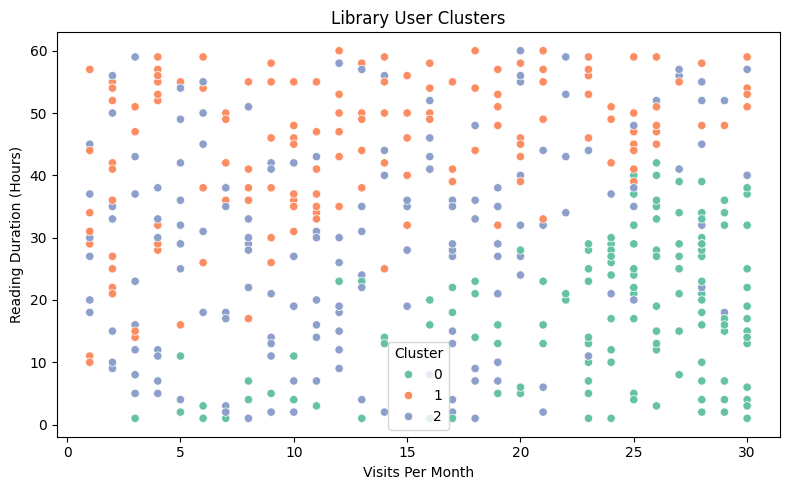

In [8]:
# Cluster visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Visit_Frequency_Per_Month",
    y="Reading_Duration_Hours",
    hue="Cluster",
    palette="Set2"
)
plt.title("Library User Clusters")
plt.xlabel("Visits Per Month")
plt.ylabel("Reading Duration (Hours)")
plt.tight_layout()
plt.show()

## 7. Personalized Recommendation System
Recommend reading resources based on a student's preferred genre.

In [9]:
def recommend_book(reg_no):
    student = df[df["Registration_No"] == reg_no]

    if student.empty:
        print("Student not found.")
        return

    genre = student["Preferred_Genre"].mode()[0]

    print("Student:", student["Student_Name"].iloc[0])
    print("Preferred Genre:", genre)
    print("\nRecommendation:")
    print(f"Explore more books from the {genre} genre.")
    print(f"Explore digital resources related to {genre}.")

# Example
recommend_book(df["Registration_No"].iloc[0])

Student: PALLAMALA MUNI SIVA TEJA
Preferred Genre: Non-Fiction

Recommendation:
Explore more books from the Non-Fiction genre.
Explore digital resources related to Non-Fiction.


## 8. New Books Purchase Recommendation

In [10]:
genre_demand = df["Preferred_Genre"].value_counts().reset_index()
genre_demand.columns = ["Genre", "Demand"]

display(genre_demand)

top_genre = genre_demand.iloc[0]["Genre"]

print("Library Recommendation:")
print(f"Purchase more books from the {top_genre} genre because it has the highest student demand.")

,Genre,Demand
0,Science,82
1,Technology,80
2,History,75
3,Non-Fiction,75
4,Business,65
5,Literature,65
6,Fiction,58


Library Recommendation:
Purchase more books from the Science genre because it has the highest student demand.


In [11]:
# 9. Peak Hour Recommendation
peak_hours = df["Peak_Library_Hour"].value_counts()

print("Top Peak Hours:")
display(peak_hours.head(3))

print("Recommendation:")
print("Increase seating and staff availability during peak library hours.")

Top Peak Hours:


Peak_Library_Hour
10 AM    68
9 AM     66
4 PM     65
Name: count, dtype: int64

Recommendation:
Increase seating and staff availability during peak library hours.


## 10. Final Project Findings

1. **Apriori:** Identifies combinations of genre, visit reason and peak hours.
2. **K-Means:** Segments students into different library-usage groups.
3. **Recommendation System:** Suggests books and digital resources based on preferred genre.
4. **Purchase Recommendation:** Helps the library prioritize high-demand genres.
5. **Peak-Hour Recommendation:** Helps allocate seating and staff during busy periods.

**Note:** The current dataset does not contain a Department column, so department-wise utilization should not be fabricated. Add a real Department field if that dashboard visual is required.